In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [2]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
df = pd.read_csv('Dataset/hinglish_cyberbullying_dataset_25000.csv')

df.head()

,ID,Text,Label
0,1,You're awesome!,0
1,2,Tum jaise logon se baat nahi karte.,1
2,3,Thanks for your support yaar.,0
3,4,Teri aukaat kya hai samjhta hai?,1
4,5,"Nice effort, proud of you.",0


In [50]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      25000 non-null  int64 
 1   Text    25000 non-null  object
 2   Label   25000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 586.1+ KB
None


Label
1    15000
0    10000
Name: count, dtype: int64


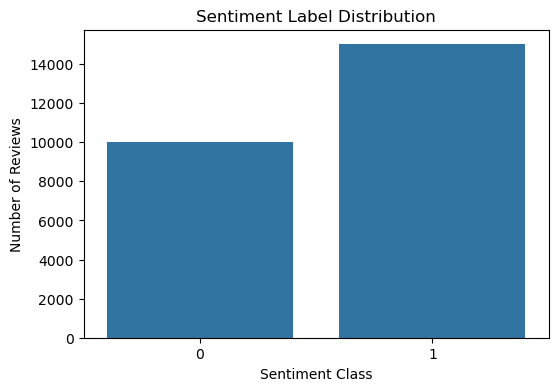

In [51]:
df = df.drop('ID', axis=1)

sentiment_counts = df['Label'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')
plt.show()

In [52]:
stemmer=PorterStemmer()
stop_words=set(stopwords.words('english'))

hinglish_stops = {'hai', 'ki', 'se', 'ko', 'mein', 'aur', 'pe', 'ka', 'ke', 'bhi', 'kya', 'yeh', 'woh'}
stop_words.update(hinglish_stops)

In [53]:
def preprocess_hinglish(text):
    # 1. Handle missing values: if the text is somehow not a string, return an empty string
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    # 3. Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Remove stop words
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return ' '.join(words)

In [57]:
df['clean_text'] = df['Text'].fillna('').apply(preprocess_hinglish)

print("Preprocessing complete!")

Preprocessing complete!


In [58]:
df['clean_text'][0]

'youre awesome'

In [59]:
df['clean_text'][51]

'teri aukaat samjhta'

In [60]:
# Convert the cleaned text to numerical features using TF-IDF
# Tell the vectorizer to look at single words AND pairs of words
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['Label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (25000, 233)
Shape of y: (25000,)


In [61]:
y=df['Label']
print(y)

0        0
1        1
2        0
3        1
4        0
        ..
24995    1
24996    1
24997    1
24998    1
24999    1
Name: Label, Length: 25000, dtype: int64


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [64]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1989
           1       1.00      1.00      1.00      3011

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



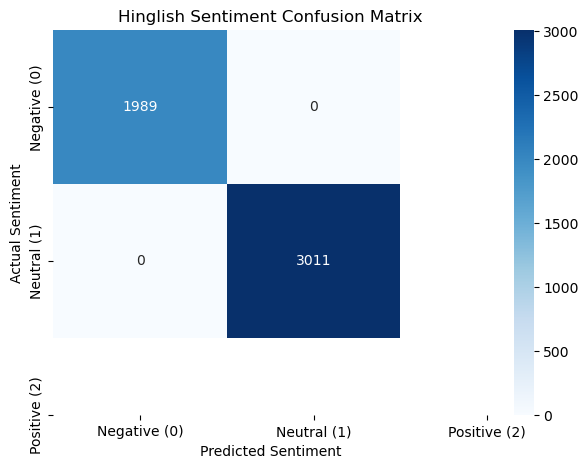

In [65]:
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Neutral (1)', 'Positive (2)'], 
            yticklabels=['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Hinglish Sentiment Confusion Matrix')
plt.show()

In [72]:
sentiment_decoder = {
    0: "Normal / Friendly ",
    1: "Negative "
}

In [73]:
def predict_custom_text(text):
    # 1. Clean the new text using your custom Hinglish function
    cleaned_text = preprocess_hinglish(text)
    
    # 2. Convert the text to numbers (Notice we use .transform, NOT .fit_transform)
    vectorized_text = vectorizer.transform([cleaned_text]).toarray()
    
    # 3. Get the prediction number (0, 1, or 2)
    predicted_number = model.predict(vectorized_text)[0]
    
    # 4. Return the decoded label
    return sentiment_decoder[predicted_number]

### Testing the Model (Interactive Mini-App)
To make testing easier and more intuitive, let's build a quick interactive widget right here in the notebook so we can type custom Hinglish sentences and see the model's predictions in real-time!

In [74]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
# 1. Create the UI elements
text_box = widgets.Textarea(
    value='',
    placeholder='Type your Hinglish review here... (e.g., bhai kya movie thi, maza aa gaya)',
    description='Review:',
    layout=widgets.Layout(width='70%', height='80px')
)

predict_button = widgets.Button(
    description='Predict Sentiment',
    button_style='success',
    icon='check'
)

output_area = widgets.Output()

In [76]:
# 2. Define the button click action
def on_button_click(b):
    with output_area:
        clear_output() # Clear previous results
        user_input = text_box.value
        
        if user_input.strip() == '':
            print("Please type a review you want to analyze first!")
        else:
            result = predict_custom_text(user_input)
            print(f" Your Review: '{user_input}'")
            print(f"AI Prediction: {result}")

In [77]:
# 3. Link the button and display the app
predict_button.on_click(on_button_click)
display(text_box, predict_button, output_area)

Textarea(value='', description='Review:', layout=Layout(height='80px', width='70%'), placeholder='Type your Hi…

Button(button_style='success', description='Predict Sentiment', icon='check', style=ButtonStyle())

Output()